<a href="https://colab.research.google.com/github/AnirudhSKrishnan/InductionMotorTwin/blob/main/inductionmotor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# If needed in Colab (run this in a separate cell):
# !pip install -q torch torchvision torchaudio scikit-learn pandas

"""
Train an LSTM-based digital twin model for the induction motor dataset
exported from Simulink as `im_no_load_run1.csv`.

Expected CSV columns (from your file):
    Time
    sig1_1, sig1_2, sig1_3          # phase currents (Iabc)
    sig1_vabcTT                     # mostly zeros, not used
    sig2_1, sig2_2, sig2_3          # phase voltages (Vabc)
    sig1_vdscTT                     # DC bus voltage
    x_Te_                           # electromagnetic torque
    sig1_wTT                        # mechanical speed
"""

from __future__ import annotations

import json
from dataclasses import dataclass
from pathlib import Path
from typing import List, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset


# ---------------------------------------------------------------------------
# Device
# ---------------------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# ---------------------------------------------------------------------------
# Data loading helpers
# ---------------------------------------------------------------------------

def _parse_time_column(raw_series: pd.Series) -> pd.Series:
    """Convert time strings like '0.001 sec' into float seconds as a pandas Series."""
    cleaned = raw_series.astype(str).str.replace(" sec", "", regex=False)
    return pd.to_numeric(cleaned, errors="coerce")


def load_motor_dataframe(csv_path: Path | str) -> pd.DataFrame:
    """Load motor CSV, normalize time column, sort and dedupe."""
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)

    if "Time" in df.columns:
        df["Time"] = _parse_time_column(df["Time"])

    df = df.sort_values("Time", kind="mergesort").drop_duplicates(subset="Time")
    df = df.reset_index(drop=True)
    return df


# ---------------------------------------------------------------------------
# Sequence config and dataset
# ---------------------------------------------------------------------------

@dataclass(frozen=True)
class SequenceConfig:
    history: int = 50   # number of past samples for each input sequence
    horizon: int = 1    # how many future time steps to predict
    batch_size: int = 256


class SequenceDataset(Dataset):
    """
    Turn continuous time-series (features, targets) into overlapping sequences
    for next-step (horizon=1) or multi-step forecasting.
    """

    def __init__(
        self,
        features: np.ndarray,
        targets: np.ndarray,
        cfg: SequenceConfig,
    ) -> None:
        """
        features: [T, F]
        targets:  [T, D]
        """
        self.features = features
        self.targets = targets
        self.cfg = cfg
        self.indices = self._build_indices()

    def _build_indices(self) -> List[int]:
        """Indices at which we take the last point of the history window."""
        start = self.cfg.history
        end = len(self.features) - self.cfg.horizon + 1
        if end <= start:
            # No valid sequences
            return []
        return list(range(start, end))

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        anchor = self.indices[idx]
        start = anchor - self.cfg.history
        stop = anchor
        x = self.features[start:stop]                      # [history, F]
        y = self.targets[anchor : anchor + self.cfg.horizon]  # [horizon, D]
        return torch.from_numpy(x).float(), torch.from_numpy(y).float()


# ---------------------------------------------------------------------------
# LSTM model and training utilities
# ---------------------------------------------------------------------------

class LSTMForecaster(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, output_dim: int) -> None:
        super().__init__()
        self.rnn = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, T, F]  ->  output: [B, D]
        """
        seq_out, _ = self.rnn(x)         # [B, T, H]
        last_hidden = seq_out[:, -1, :]  # [B, H]
        return self.head(last_hidden)    # [B, D]


def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optim: torch.optim.Optimizer,
) -> float:
    model.train()
    total_loss = 0.0
    total_samples = 0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(DEVICE)          # [B, T, F]
        batch_y = batch_y.to(DEVICE)          # [B, horizon, D]

        optim.zero_grad()
        preds = model(batch_x)                # [B, D]
        target = batch_y[:, 0, :]             # [B, D]

        loss = criterion(preds, target)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optim.step()

        bs = batch_x.size(0)
        total_loss += loss.item() * bs
        total_samples += bs

    return total_loss / max(total_samples, 1)


def eval_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> float:
    model.eval()
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            preds = model(batch_x)
            target = batch_y[:, 0, :]

            loss = criterion(preds, target)

            bs = batch_x.size(0)
            total_loss += loss.item() * bs
            total_samples += bs

    return total_loss / max(total_samples, 1)


def compute_metrics(
    model: nn.Module,
    loader: DataLoader,
    target_scaler: StandardScaler,
    target_columns: Sequence[str],
) -> dict:
    """Compute RMSE and R² per target on the (denormalized) test set."""
    model.eval()
    preds_list: List[np.ndarray] = []
    target_list: List[np.ndarray] = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            preds = model(batch_x).cpu().numpy()          # [B, D]
            preds_list.append(preds)
            target_list.append(batch_y[:, 0, :].cpu().numpy())

    if not preds_list:
        return {}

    preds_norm = np.concatenate(preds_list, axis=0)
    target_norm = np.concatenate(target_list, axis=0)

    preds_real = target_scaler.inverse_transform(preds_norm)
    target_real = target_scaler.inverse_transform(target_norm)

    metrics = {}
    for col_idx, column in enumerate(target_columns):
        rmse = root_mean_squared_error(target_real[:, col_idx], preds_real[:, col_idx])
        r2 = r2_score(target_real[:, col_idx], preds_real[:, col_idx])
        metrics[column] = {"rmse": float(rmse), "r2": float(r2)}

    return metrics


def chronological_split(
    features: np.ndarray,
    targets: np.ndarray,
    train_ratio: float,
    val_ratio: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Split (features, targets) into train/val/test along the time axis."""
    total = len(features)
    train_end = int(total * train_ratio)
    val_end = int(total * (train_ratio + val_ratio))
    return (
        features[:train_end],
        targets[:train_end],
        features[train_end:val_end],
        targets[train_end:val_end],
        features[val_end:],
        targets[val_end:],
    )


# ---------------------------------------------------------------------------
# Main training pipeline
# ---------------------------------------------------------------------------

def main() -> None:
    # === Paths ===
    # In Colab: upload im_no_load_run1.csv to /content and set this to Path("/content/im_no_load_run1.csv")
    CSV_PATH = Path("im_no_load_run1.csv")
    OUTPUT_DIR = Path("artifacts")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # === Columns from YOUR CSV ===
    # Inputs (features): currents, phase voltages, DC bus
    FEATURE_COLS = [
        "sig1_1",       # phase current A
        "sig1_2",       # phase current B
        "sig1_3",       # phase current C
        "sig2_1",       # phase voltage A
        "sig2_2",       # phase voltage B
        "sig2_3",       # phase voltage C
        "sig1_vdscTT",  # DC bus voltage
    ]

    # Outputs (targets): torque and speed
    TARGET_COLS = [
        "x_Te_",        # electromagnetic torque
        "sig1_wTT",     # mechanical speed
    ]

    # === Hyperparameters ===
    EPOCHS        = 25
    HIDDEN_SIZE   = 128
    NUM_LAYERS    = 2
    LEARNING_RATE = 1e-3
    HISTORY       = 50
    BATCH_SIZE    = 256
    TRAIN_RATIO   = 0.7
    VAL_RATIO     = 0.15

    print("Loading CSV from:", CSV_PATH)
    df = load_motor_dataframe(CSV_PATH)

    print("Columns in CSV:", df.columns.tolist())
    missing_columns = set(FEATURE_COLS + TARGET_COLS) - set(df.columns)
    if missing_columns:
        raise ValueError(f"Columns not found in CSV: {sorted(missing_columns)}")

    # Extract arrays
    features = df[FEATURE_COLS].to_numpy(dtype=np.float32)   # [T, F]
    targets  = df[TARGET_COLS].to_numpy(dtype=np.float32)    # [T, D]

    # Scale (standardize) features and targets
    feature_scaler = StandardScaler()
    target_scaler  = StandardScaler()

    features_scaled = feature_scaler.fit_transform(features)
    targets_scaled  = target_scaler.fit_transform(targets)

    cfg = SequenceConfig(history=HISTORY, horizon=1, batch_size=BATCH_SIZE)

    # Chronological split
    (
        f_train,
        t_train,
        f_val,
        t_val,
        f_test,
        t_test,
    ) = chronological_split(features_scaled, targets_scaled, TRAIN_RATIO, VAL_RATIO)

    print("Raw lengths (T):", len(features))
    print("Train/Val/Test sizes (T):", len(f_train), len(f_val), len(f_test))

    # Build Sequence datasets
    train_ds = SequenceDataset(f_train, t_train, cfg)
    val_ds   = SequenceDataset(f_val, t_val, cfg)
    test_ds  = SequenceDataset(f_test, t_test, cfg)

    print("SequenceDataset sizes:",
          "train =", len(train_ds),
          "val =", len(val_ds),
          "test =", len(test_ds))

    if len(train_ds) == 0 or len(val_ds) == 0 or len(test_ds) == 0:
        print("WARNING: one of the sequence datasets is empty. "
              "Check history/horizon vs time length.")

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size)
    test_loader  = DataLoader(test_ds, batch_size=cfg.batch_size)

    # Build model
    model = LSTMForecaster(
        input_size=features.shape[1],
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        output_dim=len(TARGET_COLS),
    ).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Training loop with early stopping
    best_val = float("inf")
    patience = max(3, EPOCHS // 5)
    wait = 0
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer)
        val_loss   = eval_epoch(model, val_loader, criterion)

        if val_loss < best_val:
            best_val = val_loss
            wait = 0
            best_state = model.state_dict()
        else:
            wait += 1

        print(f"Epoch {epoch:03d} | train_loss={train_loss:.6e} | val_loss={val_loss:.6e}")

        if wait >= patience:
            print("Early stopping triggered.")
            break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # Evaluate on test set
    metrics = compute_metrics(model, test_loader, target_scaler, TARGET_COLS)
    print("\nTest metrics:")
    for column, stat in metrics.items():
        print(f"  {column}: rmse={stat['rmse']:.6f}, r2={stat['r2']:.4f}")

    # Save artifacts
    torch.save(
        {
            "model_state": model.state_dict(),
            "feature_scaler_mean": feature_scaler.mean_,
            "feature_scaler_scale": feature_scaler.scale_,
            "target_scaler_mean": target_scaler.mean_,
            "target_scaler_scale": target_scaler.scale_,
            "feature_columns": FEATURE_COLS,
            "target_columns": TARGET_COLS,
            "config": {
                "history": cfg.history,
                "horizon": cfg.horizon,
                "hidden_size": HIDDEN_SIZE,
                "layers": NUM_LAYERS,
            },
        },
        OUTPUT_DIR / "lstm_digital_twin.pt",
    )

    with open(OUTPUT_DIR / "metrics.json", "w", encoding="utf-8") as fp:
        json.dump(metrics, fp, indent=2)

    metadata = {
        "train_samples": len(train_ds),
        "val_samples": len(val_ds),
        "test_samples": len(test_ds),
        "train_ratio": TRAIN_RATIO,
        "val_ratio": VAL_RATIO,
        "history": cfg.history,
        "batch_size": cfg.batch_size,
        "epochs_trained": epoch,
    }
    with open(OUTPUT_DIR / "training_run.json", "w", encoding="utf-8") as fp:
        json.dump(metadata, fp, indent=2)

    print("\nArtifacts saved to:", OUTPUT_DIR.resolve())


if __name__ == "__main__":
    main()


Using device: cuda
Loading CSV from: im_no_load_run1.csv
Columns in CSV: ['Time', 'sig1_1', 'sig1_2', 'sig1_3', 'sig1_vabcTT', 'sig2_1', 'sig2_2', 'sig2_3', 'sig1_vdscTT', 'x_Te_', 'sig1_wTT']
Raw lengths (T): 110875
Train/Val/Test sizes (T): 77612 16631 16632
SequenceDataset sizes: train = 77562 val = 16581 test = 16582
Epoch 001 | train_loss=5.889018e-01 | val_loss=4.425222e-03
Epoch 002 | train_loss=3.240174e-01 | val_loss=6.002317e-03
Epoch 003 | train_loss=2.153128e-01 | val_loss=2.469607e-03
Epoch 004 | train_loss=1.864075e-01 | val_loss=1.565115e-03
Epoch 005 | train_loss=1.587409e-01 | val_loss=1.598611e-03
Epoch 006 | train_loss=1.364572e-01 | val_loss=2.006568e-03
Epoch 007 | train_loss=1.244860e-01 | val_loss=1.452738e-03
Epoch 008 | train_loss=1.000304e-01 | val_loss=1.270324e-03
Epoch 009 | train_loss=9.207074e-02 | val_loss=1.012694e-03
Epoch 010 | train_loss=1.084129e-01 | val_loss=9.091864e-04
Epoch 011 | train_loss=9.652830e-02 | val_loss=1.171603e-03
Epoch 012 | train

Using device: cuda
FEATURE_COLS: ['sig1_1', 'sig1_2', 'sig1_3', 'sig2_1', 'sig2_2', 'sig2_3', 'sig1_vdscTT']
TARGET_COLS : ['x_Te_', 'sig1_wTT']
Config      : {'history': 50, 'horizon': 1, 'hidden_size': 128, 'layers': 2}
Model restored.
CSV columns: ['Time', 'sig1_1', 'sig1_2', 'sig1_3', 'sig1_vabcTT', 'sig2_1', 'sig2_2', 'sig2_3', 'sig1_vdscTT', 'x_Te_', 'sig1_wTT']

Per-target metrics (RMSE, R²):
x_Te_: RMSE=0.052941, R²=0.9235
sig1_wTT: RMSE=0.606101, R²=0.9995


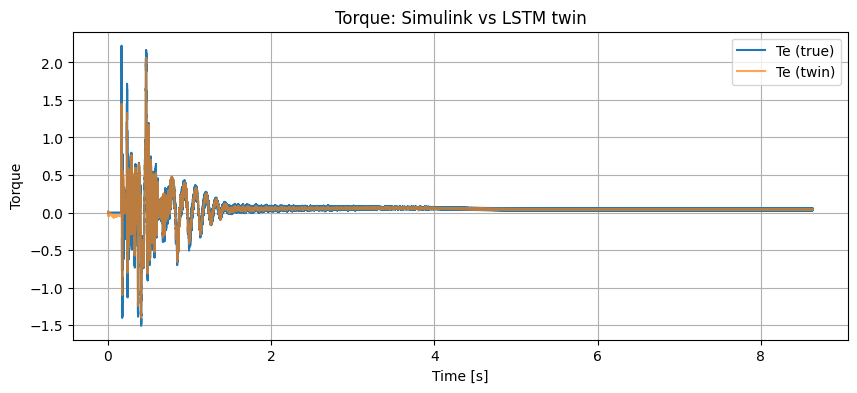

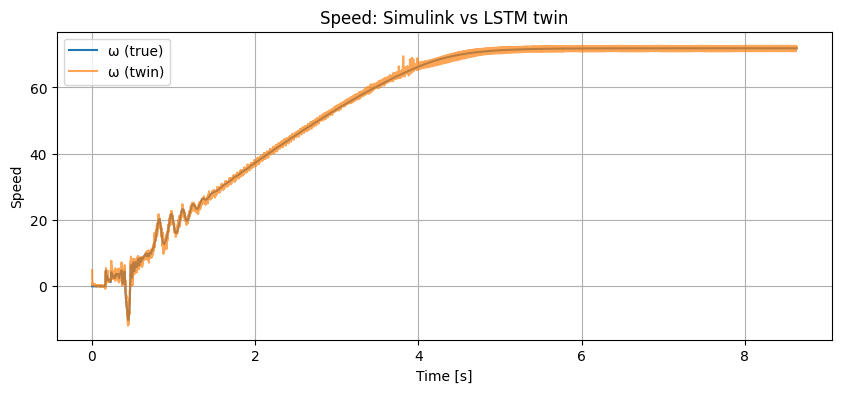

In [ ]:
# If needed in Colab, run this cell directly.
# Make sure you have uploaded BOTH:
#   - lstm_digital_twin.pt
#   - im_no_load_run1.csv
# to the current working directory (usually /content).

!pip install -q torch torchvision torchaudio scikit-learn pandas

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# --------------------------------------------------------
# Device
# --------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# --------------------------------------------------------
# Helpers to load the CSV
# --------------------------------------------------------
def _parse_time_column(raw_series: pd.Series) -> pd.Series:
    cleaned = raw_series.astype(str).str.replace(" sec", "", regex=False)
    return pd.to_numeric(cleaned, errors="coerce")

def load_motor_dataframe(csv_path: str | Path) -> pd.DataFrame:
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)
    if "Time" in df.columns:
        df["Time"] = _parse_time_column(df["Time"])
    df = df.sort_values("Time", kind="mergesort").drop_duplicates(subset="Time")
    df = df.reset_index(drop=True)
    return df


# --------------------------------------------------------
# Recreate LSTM architecture (must match training)
# --------------------------------------------------------
class LSTMForecaster(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, output_dim: int) -> None:
        super().__init__()
        self.rnn = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        seq_out, _ = self.rnn(x)         # [B, T, H]
        last_hidden = seq_out[:, -1, :]  # [B, H]
        return self.head(last_hidden)    # [B, D]


# --------------------------------------------------------
# Load checkpoint and rebuild model + scalers
# --------------------------------------------------------
ckpt_path = Path("lstm_digital_twin.pt")  # change if stored elsewhere
ckpt = torch.load(ckpt_path, map_location=DEVICE,weights_only=False)

FEATURE_COLS = ckpt["feature_columns"]
TARGET_COLS  = ckpt["target_columns"]
cfg_dict     = ckpt["config"]

print("FEATURE_COLS:", FEATURE_COLS)
print("TARGET_COLS :", TARGET_COLS)
print("Config      :", cfg_dict)

# Rebuild scalers
feature_scaler = StandardScaler()
feature_scaler.mean_  = ckpt["feature_scaler_mean"]
feature_scaler.scale_ = ckpt["feature_scaler_scale"]
feature_scaler.var_   = feature_scaler.scale_ ** 2

target_scaler = StandardScaler()
target_scaler.mean_  = ckpt["target_scaler_mean"]
target_scaler.scale_ = ckpt["target_scaler_scale"]
target_scaler.var_   = target_scaler.scale_ ** 2

HISTORY     = cfg_dict["history"]
HIDDEN_SIZE = cfg_dict["hidden_size"]
NUM_LAYERS  = cfg_dict["layers"]

# Rebuild model and load weights
model = LSTMForecaster(
    input_size=len(FEATURE_COLS),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_dim=len(TARGET_COLS),
).to(DEVICE)

model.load_state_dict(ckpt["model_state"])
model.eval()
print("Model restored.")


# --------------------------------------------------------
# Load CSV and prepare inputs/targets
# --------------------------------------------------------
csv_path = "im_no_load_run1.csv"  # change if needed
df = load_motor_dataframe(csv_path)

print("CSV columns:", df.columns.tolist())

features = df[FEATURE_COLS].to_numpy(dtype=np.float32)  # [T, F]
targets  = df[TARGET_COLS].to_numpy(dtype=np.float32)   # [T, D]
time     = df["Time"].to_numpy()

# Scale using restored scalers
X_scaled = feature_scaler.transform(features)
Y_scaled = target_scaler.transform(targets)


# --------------------------------------------------------
# Sliding-window inference over the full record
# --------------------------------------------------------
history = HISTORY
T = len(X_scaled)

preds_scaled = []
true_scaled  = []
valid_times  = []

with torch.no_grad():
    for anchor in range(history, T):
        start = anchor - history
        stop  = anchor

        x_win = X_scaled[start:stop]                     # [history, F]
        x_tensor = torch.from_numpy(x_win[None, ...]).to(DEVICE)  # [1, history, F]

        y_hat_scaled = model(x_tensor).cpu().numpy()[0]  # [D]

        preds_scaled.append(y_hat_scaled)
        true_scaled.append(Y_scaled[anchor])
        valid_times.append(time[anchor])

preds_scaled = np.stack(preds_scaled, axis=0)  # [T-history, D]
true_scaled  = np.stack(true_scaled,  axis=0)
valid_times  = np.array(valid_times)


# --------------------------------------------------------
# Back to physical units + simple metrics
# --------------------------------------------------------
preds = target_scaler.inverse_transform(preds_scaled)
true  = target_scaler.inverse_transform(true_scaled)

print("\nPer-target metrics (RMSE, R²):")
for j, name in enumerate(TARGET_COLS):
    mse  = mean_squared_error(true[:, j], preds[:, j])
    rmse = float(np.sqrt(mse))
    r2   = float(r2_score(true[:, j], preds[:, j]))
    print(f"{name}: RMSE={rmse:.6f}, R²={r2:.4f}")


# --------------------------------------------------------
# Plot torque and speed: true vs twin
# --------------------------------------------------------
Te_idx = TARGET_COLS.index("x_Te_")
w_idx  = TARGET_COLS.index("sig1_wTT")

plt.figure(figsize=(10,4))
plt.plot(valid_times, true[:, Te_idx], label="Te (true)")
plt.plot(valid_times, preds[:, Te_idx], label="Te (twin)", alpha=0.7)
plt.xlabel("Time [s]")
plt.ylabel("Torque")
plt.title("Torque: Simulink vs LSTM twin")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(valid_times, true[:, w_idx], label="ω (true)")
plt.plot(valid_times, preds[:, w_idx], label="ω (twin)", alpha=0.7)
plt.xlabel("Time [s]")
plt.ylabel("Speed")
plt.title("Speed: Simulink vs LSTM twin")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# 4) Inverse-transform to physical units
preds = target_scaler.inverse_transform(preds_scaled)
true  = target_scaler.inverse_transform(true_scaled)

# Quick RMSE and R² per target
from sklearn.metrics import mean_squared_error, r2_score

for j, name in enumerate(TARGET_COLS):
    mse  = mean_squared_error(true[:, j], preds[:, j])
    rmse = np.sqrt(mse)
    r2   = r2_score(true[:, j], preds[:, j])
    print(f"{name}: RMSE={rmse:.6f}, R²={r2:.4f}")


NameError: name 'feature_cols' is not defined

In [ ]:
import matplotlib.pyplot as plt

Te_idx = TARGET_COLS.index("x_Te_")
w_idx  = TARGET_COLS.index("sig1_wTT")

# Torque
plt.figure(figsize=(10,4))
plt.plot(valid_times, true[:, Te_idx], label="Te (true)")
plt.plot(valid_times, preds[:, Te_idx], label="Te (twin)", alpha=0.7)
plt.xlabel("Time [s]")
plt.ylabel("Torque")
plt.title("Torque: Simulink vs LSTM Twin")
plt.grid(True)
plt.legend()
plt.show()

# Speed
plt.figure(figsize=(10,4))
plt.plot(valid_times, true[:, w_idx], label="ω (true)")
plt.plot(valid_times, preds[:, w_idx], label="ω (twin)", alpha=0.7)
plt.xlabel("Time [s]")
plt.ylabel("Speed")
plt.title("Speed: Simulink vs LSTM Twin")
plt.grid(True)
plt.legend()
plt.show()


NameError: name 'target_cols' is not defined